## Example

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from conformal_envelopes import ConformalSetModel

from conformal_envelopes import evaluate_prediction_sets

train = pd.read_csv("train_example.csv")
test = pd.read_csv("test_example.csv")

print(train.head())
print()
print(test.head())

        ID   score_1   score_2   score_3 label
0  id_0000  0.373086  0.330935  0.558781     B
1  id_0001  0.465200  0.284044  0.493325     B
2  id_0002  0.889371  0.661489  0.821468     A
3  id_0003  0.959575  0.732291  0.904879     A
4  id_0004  0.355465  0.302119  0.324708     B

        ID   score_1   score_2   score_3 label
0  id_0200  0.309090       NaN  0.390388     B
1  id_0201  0.895580  0.765823  0.817216     A
2  id_0202       NaN  0.444927  0.463014     B
3  id_0203       NaN  0.486706  0.429451     B
4  id_0204  0.306971  0.234696       NaN     B


### Strip Model

{'A': {'label': 'A', 'method': 'strip', 'columns': ['score_1', 'score_2', 'score_3'], 'alpha': 0.1, 'shape_size': 49, 'calibration_size': 50, 'parameters': {}, 'idx_s1': array([ 1, 74, 53, 64, 80, 17, 29, 25, 49, 68, 84, 61, 33, 54, 44, 37, 86,
       45, 72, 96, 38, 23, 22, 90, 52, 65, 59, 36, 92, 55, 94, 13, 89, 63,
       30, 77, 97, 70, 32, 28,  6, 79, 83, 34,  0,  7, 67, 82, 91]), 'idx_s2': array([20, 47, 76, 88, 16, 39,  8, 98, 69, 48, 11, 35, 15, 27, 51, 73, 66,
        3, 14, 78, 87, 81, 10, 58, 46, 24, 12, 42, 50,  2, 43, 41,  5,  4,
       21, 31, 18, 40, 56, 71, 95, 85, 93, 75, 19, 26, 62, 57,  9, 60]), 'envelope': {'method': 'strip', 'bin_edges': array([[0.        , 0.0372534 , 0.0745068 , 0.11176021, 0.14901361,
        0.18626701, 0.22352041, 0.26077382, 0.29802722],
       [0.01976782, 0.06574134, 0.11171487, 0.15768839, 0.20366192,
        0.24963544, 0.29560897, 0.3415825 , 0.38755602],
       [0.0265021 , 0.06929195, 0.11208179, 0.15487164, 0.19766149,
        0.24045

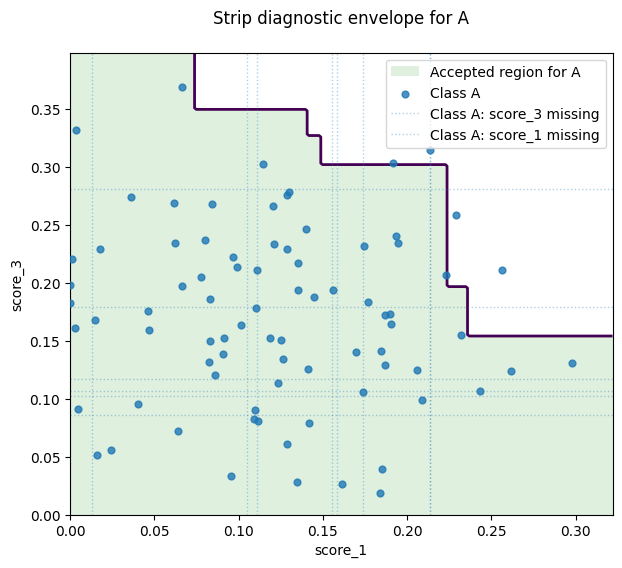

In [2]:
# creating the model
model = ConformalSetModel(method="strip", alpha=0.1, random_state=13,)

# Fitting the model using training file
# takes the training data, separates the observations by class (A and B), splits each class into S1 and S2, 
# learns the Collapsed envelope shape from S1, and calibrates it using S2.
model.fit(train)

# inspecting the constructed envelopes
print(model.get_envelopes())

# using the learnt envelopes to make the conformal prediction sets for the test data
predictions = model.predict(test)
print(predictions)

# comparing each set with the true label in the test data
results = evaluate_prediction_sets(predictions["prediction_set"], test["label"])
print(results)

# plotting 2D
model.plot(x="score_1", y="score_3", label="A")
plt.show()

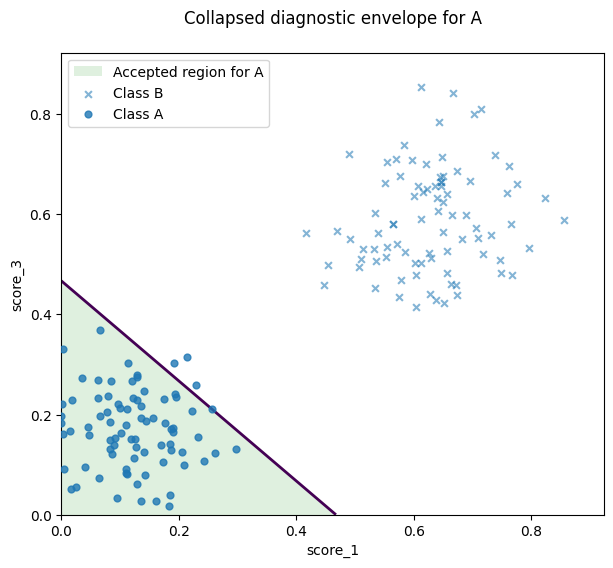

In [9]:
model.plot(x="score_1", y="score_3", label="A", show_other_classes=True, show_missing=False)
plt.show()

### Radial Model

{'A': {'label': 'A', 'method': 'radial', 'columns': [np.str_('score_1'), np.str_('score_2'), np.str_('score_3')], 'alpha': 0.1, 'shape_size': 49, 'calibration_size': 50, 'parameters': {}, 'idx_s1': array([ 1, 74, 53, 64, 80, 17, 29, 25, 49, 68, 84, 61, 33, 54, 44, 37, 86,
       45, 72, 96, 38, 23, 22, 90, 52, 65, 59, 36, 92, 55, 94, 13, 89, 63,
       30, 77, 97, 70, 32, 28,  6, 79, 83, 34,  0,  7, 67, 82, 91]), 'idx_s2': array([20, 47, 76, 88, 16, 39,  8, 98, 69, 48, 11, 35, 15, 27, 51, 73, 66,
        3, 14, 78, 87, 81, 10, 58, 46, 24, 12, 42, 50,  2, 43, 41,  5,  4,
       21, 31, 18, 40, 56, 71, 95, 85, 93, 75, 19, 26, 62, 57,  9, 60]), 'envelope': {'method': 'radial', 'U': array([[0.53927929, 0.5584559 , 0.63032124],
       [0.38998718, 0.19274635, 0.90042148],
       [0.50829663, 0.57218175, 0.6436168 ],
       [0.21598809, 0.96272397, 0.16282416],
       [0.72324679, 0.68723123, 0.06802436],
       [0.17309404, 0.98490294, 0.00215787],
       [0.17130164, 0.7534682 , 0.63477667

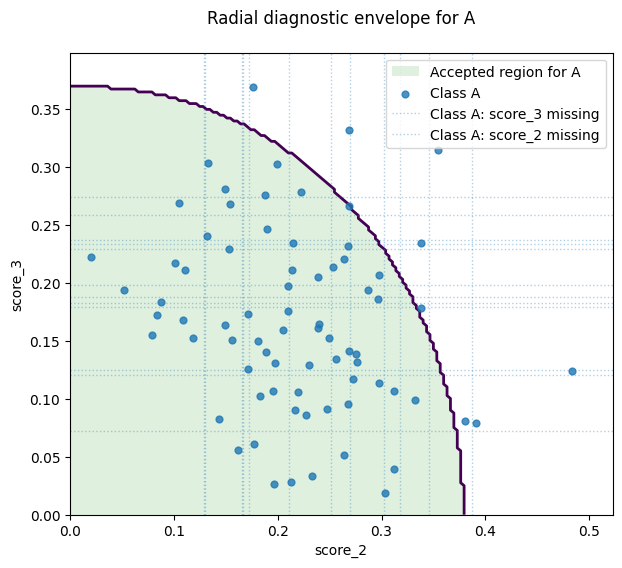

In [4]:
# creating the model
model = ConformalSetModel(method="radial", alpha=0.1, random_state=13,)

# Fitting the model using training file
# takes the training data, separates the observations by class (A and B), splits each class into S1 and S2, 
# learns the Collapsed envelope shape from S1, and calibrates it using S2.
model.fit(train)

# inspecting the constructed envelopes
print(model.get_envelopes())

# using the learnt envelopes to make the conformal prediction sets for the test data
predictions = model.predict(test)
print(predictions)

# comparing each set with the true label in the test data
results = evaluate_prediction_sets(predictions["prediction_set"], test["label"])
print(results)

# plotting 2D
model.plot(x="score_2", y="score_3", label="A")
plt.show()

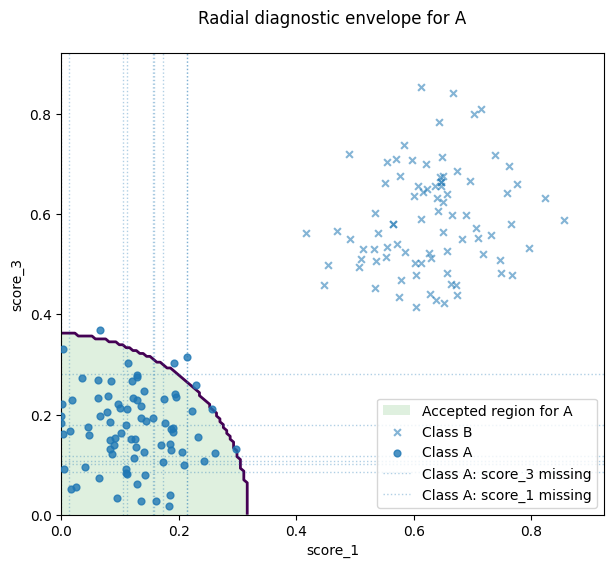

In [5]:
model.plot(x="score_1", y="score_3", label="A", show_other_classes=True,)
plt.show()

### Collapsed Model

{'A': {'label': 'A', 'method': 'collapsed', 'columns': [np.str_('score_1'), np.str_('score_2'), np.str_('score_3')], 'alpha': 0.1, 'shape_size': 49, 'calibration_size': 50, 'parameters': {}, 'idx_s1': array([ 1, 74, 53, 64, 80, 17, 29, 25, 49, 68, 84, 61, 33, 54, 44, 37, 86,
       45, 72, 96, 38, 23, 22, 90, 52, 65, 59, 36, 92, 55, 94, 13, 89, 63,
       30, 77, 97, 70, 32, 28,  6, 79, 83, 34,  0,  7, 67, 82, 91]), 'idx_s2': array([20, 47, 76, 88, 16, 39,  8, 98, 69, 48, 11, 35, 15, 27, 51, 73, 66,
        3, 14, 78, 87, 81, 10, 58, 46, 24, 12, 42, 50,  2, 43, 41,  5,  4,
       21, 31, 18, 40, 56, 71, 95, 85, 93, 75, 19, 26, 62, 57,  9, 60]), 'envelope': {'method': 'collapsed', 'q_tilde': 0.20891390445897287, 't_hat': 1.1663837756898863}}, 'B': {'label': 'B', 'method': 'collapsed', 'columns': [np.str_('score_1'), np.str_('score_2'), np.str_('score_3')], 'alpha': 0.1, 'shape_size': 50, 'calibration_size': 51, 'parameters': {}, 'idx_s1': array([51, 38,  4, 48,  8,  1, 92, 88, 57, 62, 7

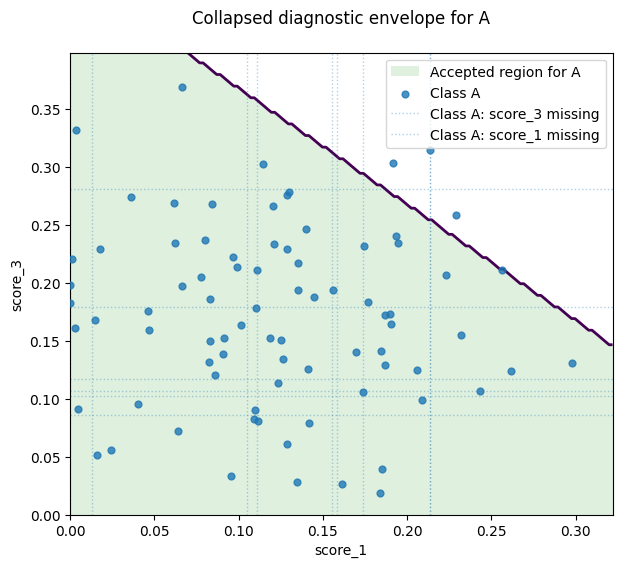

In [6]:
###### COLLAPSED MODEL ######
# creating the model
model = ConformalSetModel(method="collapsed", alpha=0.1, random_state=13)

# Fitting the model using training file
# takes the training data, separates the observations by class (A and B), splits each class into S1 and S2, 
# learns the Collapsed envelope shape from S1, and calibrates it using S2.
model.fit(train)

# inspecting the constructed envelopes
print(model.get_envelopes())

# using the learnt envelopes to make the conformal prediction sets for the test data
predictions = model.predict(test)
print(predictions)

# comparing each set with the true label in the test data
results = evaluate_prediction_sets(predictions["prediction_set"], test["label"])
print(results)

# plotting 2D
model.plot(x="score_1", y="score_3", label="A")
plt.show()

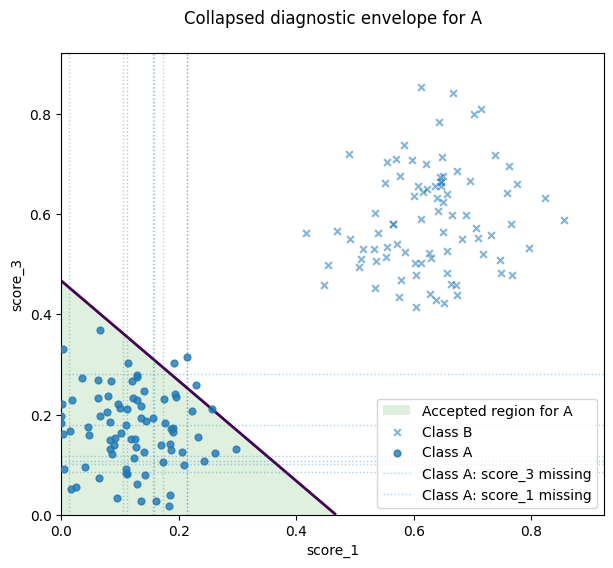

In [7]:
model.plot(x="score_1", y="score_3", label="A", show_other_classes=True,)
plt.show()